### Imports

0.6.2
gpu
0.39423576
0.39423576
0.39423576
0.39423576


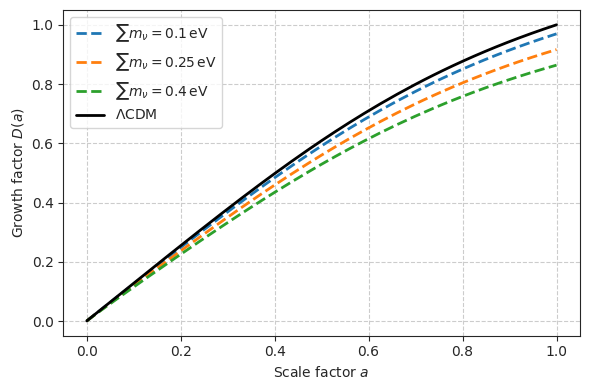

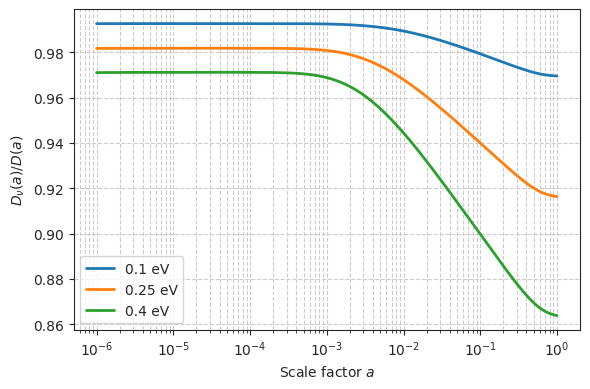

In [1]:
# Import modules
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
import jax.numpy as jnp
from discodj.cosmology.cosmology import Cosmology
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

#from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
#mpl.use("pgf")
#mpl.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "text.usetex": True,
#})

# Detect if a GPU is available
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

# Scale factor
a = jnp.geomspace(1e-6, 1.0, 500)

# Cosmology sans neutrinos
cosmo = Cosmology(
    Omega_c=0.259605,
    Omega_b=0.0488911,
    h=0.67742,
    n_s=0.96822,
    sigma8=0.808992,
    mnu=0.0
)

growth = cosmo.compute_unnormed_growth(a, 1e-6)

Norm_fact = growth["Dplus_unnormed_at_1"]
print(Norm_fact)
D1 = growth["Dplus"]  

# Stockage des résultats neutrinos
results = []

# Boucle neutrinos
for sum_masses in [0.1, 0.25, 0.4]:
    cosmo_nu = Cosmology(
        Omega_c=0.259605,
        Omega_b=0.0488911,
        h=0.67742,
        n_s=0.96822,
        sigma8=0.808992,
        mnu=sum_masses
    )

    growth_nu = cosmo_nu.compute_unnormed_growth(a, 1e-6)

    Norm_fact_nu = growth_nu["Dplus_unnormed_at_1"]
    print(Norm_fact_nu)
    D1_nu = growth_nu["Dplus"]

    results.append((sum_masses, D1_nu))

# ===== PLOT 1 : D(a)
plt.figure(figsize=(6,4))

for sum_masses, D1_nu in results:
    plt.plot(a, D1_nu, '--', lw=2,
             label=fr"$\sum m_\nu = {sum_masses}\,\mathrm{{eV}}$")

plt.plot(a, D1, color='black', lw=2, label=r'$\Lambda$CDM')

plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D(a)$')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

# ===== PLOT 2 : ratio
plt.figure(figsize=(6,4))

for sum_masses, D1_nu in results:
    plt.semilogx(a, D1_nu / D1, lw=2,
                 label=fr"{sum_masses} eV")

plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D_\nu(a) / D(a)$')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

In [2]:


#a = jnp.geomspace(1e-6, 1.0, 500)
#H = cosmo.H(a)
#H_nu = cosmo_nu.H(a)
#
#plt.figure(figsize=(7.0, 5.0))
#plt.loglog(a, H,color='blue', label=r'$H$',lw=2)  
#plt.loglog(a, H_nu,'r--', label=r'$H_{nu}$',lw=2)  
#plt.xlabel(r'Scale factor $a$')
#plt.ylabel(r'$H (km \cdot s^{-1} \cdot Mpc^{-1}$)')
#plt.grid(True, which='both', ls='--')
#plt.legend()
#plt.show()
##plt.savefig('H_DJ.pgf')
#
#
##Plot relative deviation [(H_wnu/H)-1]
#plt.figure(figsize=(7.0, 5.0))
#plt.semilogx(a, abs(H_nu/H),color='blue', label=r'$H_{nu}/H $',lw=1)  
#plt.xlabel(r'Scale factor $a$')
#plt.ylabel(r'$H_{nu}/H $')
#plt.grid(True, which='both', ls='--')
#plt.legend()
#plt.show()
##plt.savefig('Hdiff_DJ.pgf')
